# **Predicting Job Satisfaction**

### **Problem**

Predicting if a person is satisfied with his/her job or not?

### **Objective**

Aiming to predict job statisfaction among emloyees

### **About Dataset**

[https://medium.com/@datla.sa/employee-satisfaction-prediction-using-kaggle-dataset-e90c91fdf287](Website to the Dataset)

[https://raw.githubusercontent.com/sanjayvarma199/INFO6105-Data-Science-and-Engineering-Tools/main/Employee%20Satisfaction%20Index.csv](Link to the dataset)

1. Contains **14 features**

2. 'Unnamed: 0' is the **index**
    * interval data (0 to 499)
3. 'emp_id' represents **the ID of the employee** who was questioned in the survey
    * nominal data
4. 'age' represents the **age of the employee** whose ID is given by 'emp_id'.
    * ratio data
5. 'Dept' represents the **department in which that employee works**.
    * nominal data
6. 'location' represents whether the **employee lives in the suburb or the city.**
    * nominal data
7. 'education' represents the **education attainment of employees**
    * ordinal data
    * **PG    :   Post Graduate**
    * **UG    :   Under Graduate**
8. 'recruitment_type' represents **how the the employee was recruited into the job.**
    * nominal data
9. 'job_level' represents **the level of the post the employee** currently hold at the time of the survey.
    * interval data (1-5)
10. 'rating' represents **the employee performance level.**
    * interval data (1-5)
11. 'onsite represents whether the employee is **working on-site or not.**
    * Nominal data (0/1)
12. 'certifications' represents whether the **employee possesses certifications or not?**. 
    * Nominal data (0/1)
13. 'salary' represents the **salary of the employee.**
    * ratio data
14. 'awards' represents **the number awards obtained** till the data of the survey.
    * ratio data
15. 'satisfied' represents the **employee's statement of satisfaction in the job or not**.
    * Nominal data (0/1)

In [3]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv("job_satisfaction.csv")
data.head()

,Unnamed: 0,emp_id,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,0,HR8270,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,1,TECH1860,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,2,TECH6390,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,3,SAL6191,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,4,HR6734,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1


In [5]:
data.tail()

,Unnamed: 0,emp_id,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
495,495,HR5330,49,HR,Suburb,PG,On-Campus,2,5,0,6,0,29805,1
496,496,TECH9010,24,Technology,Suburb,UG,Referral,2,4,0,2,0,29805,0
497,497,MKT7801,34,Marketing,City,PG,On-Campus,1,3,0,2,0,24076,1
498,498,TECH5846,26,Technology,City,UG,On-Campus,2,1,1,1,1,29805,0
499,499,TECH7731,26,Technology,City,UG,Recruitment Agency,3,4,0,3,0,42419,0


In [6]:
data.shape

(500, 14)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        500 non-null    int64 
 1   emp_id            500 non-null    object
 2   age               500 non-null    int64 
 3   Dept              500 non-null    object
 4   location          500 non-null    object
 5   education         500 non-null    object
 6   recruitment_type  500 non-null    object
 7   job_level         500 non-null    int64 
 8   rating            500 non-null    int64 
 9   onsite            500 non-null    int64 
 10  awards            500 non-null    int64 
 11  certifications    500 non-null    int64 
 12  salary            500 non-null    int64 
 13  satisfied         500 non-null    int64 
dtypes: int64(9), object(5)
memory usage: 54.8+ KB


In [8]:
data.describe()

,Unnamed: 0,age,job_level,rating,onsite,awards,certifications,salary,satisfied
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,249.500000,38.610000,3.032000,3.072000,0.466000,4.538000,0.496000,50416.056000,0.526000
std,144.481833,9.438648,1.423738,1.425089,0.499342,2.853215,0.500485,23671.392661,0.499824
min,0.000000,23.000000,1.000000,1.000000,0.000000,0.000000,0.000000,24076.000000,0.000000
25%,124.750000,30.000000,2.000000,2.000000,0.000000,2.000000,0.000000,29805.000000,0.000000
50%,249.500000,39.000000,3.000000,3.000000,0.000000,5.000000,0.000000,42419.000000,1.000000
75%,374.250000,47.000000,4.000000,4.000000,1.000000,7.000000,1.000000,65715.000000,1.000000
max,499.000000,54.000000,5.000000,5.000000,1.000000,9.000000,1.000000,86750.000000,1.000000


In [9]:
data.nunique()

Unnamed: 0          500
emp_id              499
age                  32
Dept                  5
location              2
education             2
recruitment_type      4
job_level             5
rating                5
onsite                2
awards               10
certifications        2
salary                5
satisfied             2
dtype: int64

* **Dropping duplicated rows if any**

In [10]:
data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        500 non-null    int64 
 1   emp_id            500 non-null    object
 2   age               500 non-null    int64 
 3   Dept              500 non-null    object
 4   location          500 non-null    object
 5   education         500 non-null    object
 6   recruitment_type  500 non-null    object
 7   job_level         500 non-null    int64 
 8   rating            500 non-null    int64 
 9   onsite            500 non-null    int64 
 10  awards            500 non-null    int64 
 11  certifications    500 non-null    int64 
 12  salary            500 non-null    int64 
 13  satisfied         500 non-null    int64 
dtypes: int64(9), object(5)
memory usage: 54.8+ KB


* **'emp_id', and 'Unnamed: 0' aren't necessary for model training so we drop them**

In [11]:
data = data.drop(columns=['emp_id', 'Unnamed: 0'])
data.shape

(500, 12)

In [12]:
categorical_data = data.select_dtypes(include="object").columns
numerical_data = data.select_dtypes(exclude="object").columns

print(categorical_data.values)
print('-'*90,'\n',numerical_data.values)

print("\n\n", "Number of numerical features: ", len(numerical_data))
print("\n\n", "Number of categorical features: ", len(categorical_data))

['Dept' 'location' 'education' 'recruitment_type']
------------------------------------------------------------------------------------------ 
 ['age' 'job_level' 'rating' 'onsite' 'awards' 'certifications' 'salary'
 'satisfied']


 Number of numerical features:  8


 Number of categorical features:  4


Text(0, 0.5, 'Values')

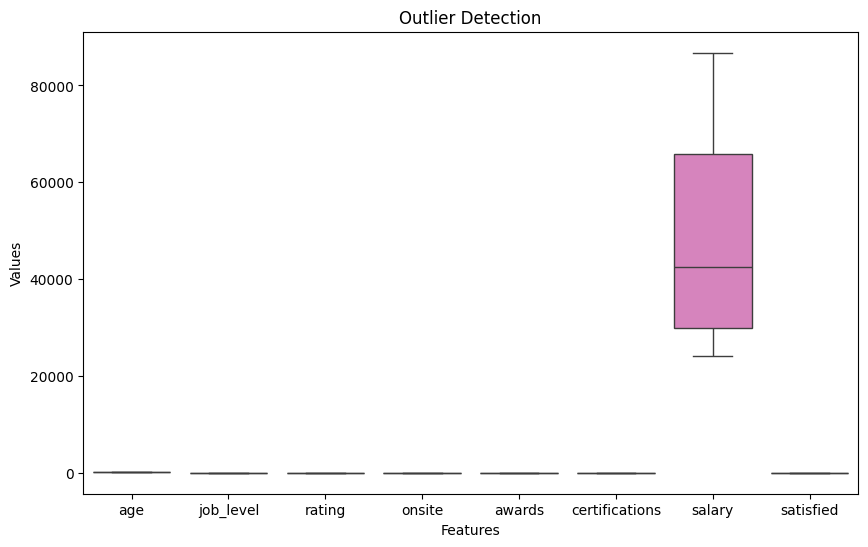

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.title("Outlier Detection")
plt.xlabel("Features")
plt.ylabel("Values")

Observation : There seems to be **no outlier**

**1. Numerical data**                                                        

* **age**                  -  ratio 
* **job_level**            -  ordinal(ordered category)
* **rating**               -  ordinal               
* **onsite**               -  nominal(binary)
* **awards**               -  ratio (count)
* **certifications**       -  nominal (binary)        
* **salary**               -  ratio
* **satisfied**            -  nominal(binary)

**2. Categorical Data**

* **Dept**                 - nominal
* **location**             - nominal
* **education**            - ordinal
* **recruitment_type**     - nominal


### **OBSERVATION**

* Number of features = 12
* Number of sample data/observations = 500
* No missing values
* No duplicated values

* Rougly Balanced dataset
    * roughly equal number of satisfied and dissatisfied employees
    * Becuase mean is rougly equal to 0.5
* Number of categorical features = 4
* Number of numerical features = 8

In [14]:
data.to_csv("job_cleaned.csv", index = False)

# **EDA**

* Data visualization
* Uncovering underlying patterns and relationships

In [15]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv("job_cleaned.csv")

In [17]:
df.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1


In [18]:
df.describe()

,age,job_level,rating,onsite,awards,certifications,salary,satisfied
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,38.610000,3.032000,3.072000,0.466000,4.538000,0.496000,50416.056000,0.526000
std,9.438648,1.423738,1.425089,0.499342,2.853215,0.500485,23671.392661,0.499824
min,23.000000,1.000000,1.000000,0.000000,0.000000,0.000000,24076.000000,0.000000
25%,30.000000,2.000000,2.000000,0.000000,2.000000,0.000000,29805.000000,0.000000
50%,39.000000,3.000000,3.000000,0.000000,5.000000,0.000000,42419.000000,1.000000
75%,47.000000,4.000000,4.000000,1.000000,7.000000,1.000000,65715.000000,1.000000
max,54.000000,5.000000,5.000000,1.000000,9.000000,1.000000,86750.000000,1.000000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               500 non-null    int64 
 1   Dept              500 non-null    object
 2   location          500 non-null    object
 3   education         500 non-null    object
 4   recruitment_type  500 non-null    object
 5   job_level         500 non-null    int64 
 6   rating            500 non-null    int64 
 7   onsite            500 non-null    int64 
 8   awards            500 non-null    int64 
 9   certifications    500 non-null    int64 
 10  salary            500 non-null    int64 
 11  satisfied         500 non-null    int64 
dtypes: int64(8), object(4)
memory usage: 47.0+ KB


**No missing values**

In [20]:
df.shape

(500, 12)

## **Target variable distribution**

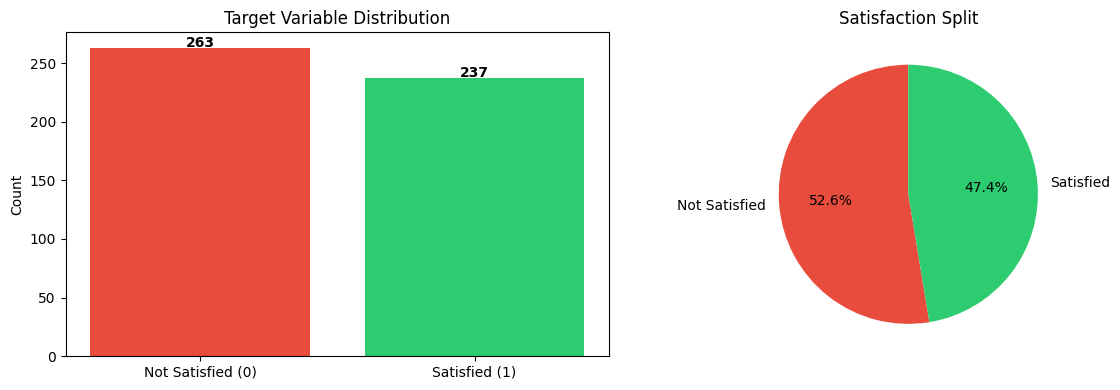

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['satisfied'].value_counts()
axes[0].bar(['Not Satisfied (0)', 'Satisfied (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Not Satisfied', 'Satisfied'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Satisfaction Split')

plt.tight_layout()
plt.show()

**52.60% of employees of this dataset are satisfied with their job**

In [22]:
df['satisfied'].value_counts()

satisfied
1    263
0    237
Name: count, dtype: int64

**There are rougly equal number of satisfied and dissatisfied employees**

## **Satisfaction rate by Department**

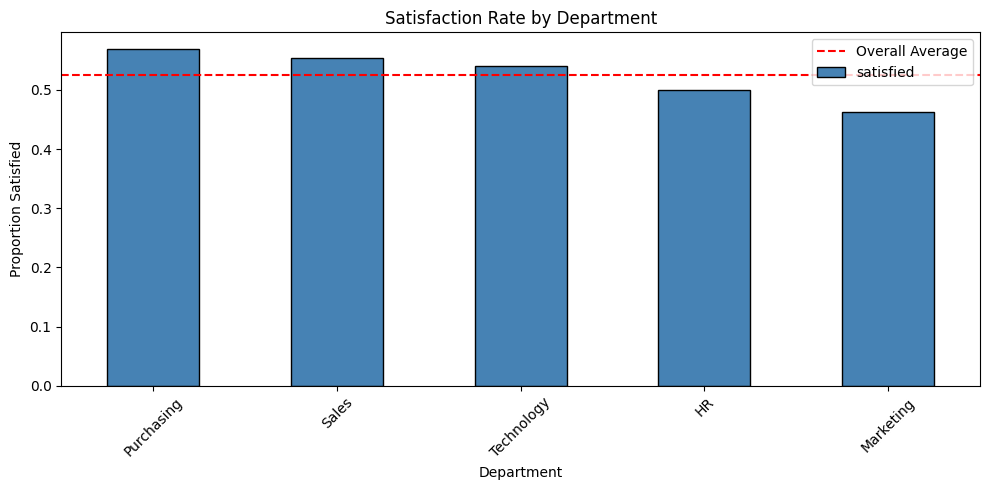

In [23]:
dept_sat = df.groupby('Dept')['satisfied'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
dept_sat.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Satisfaction Rate by Department')
plt.ylabel('Proportion Satisfied')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.axhline(df['satisfied'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.tight_layout()
plt.show()

## **Distributions of numeric features by satisfaction**

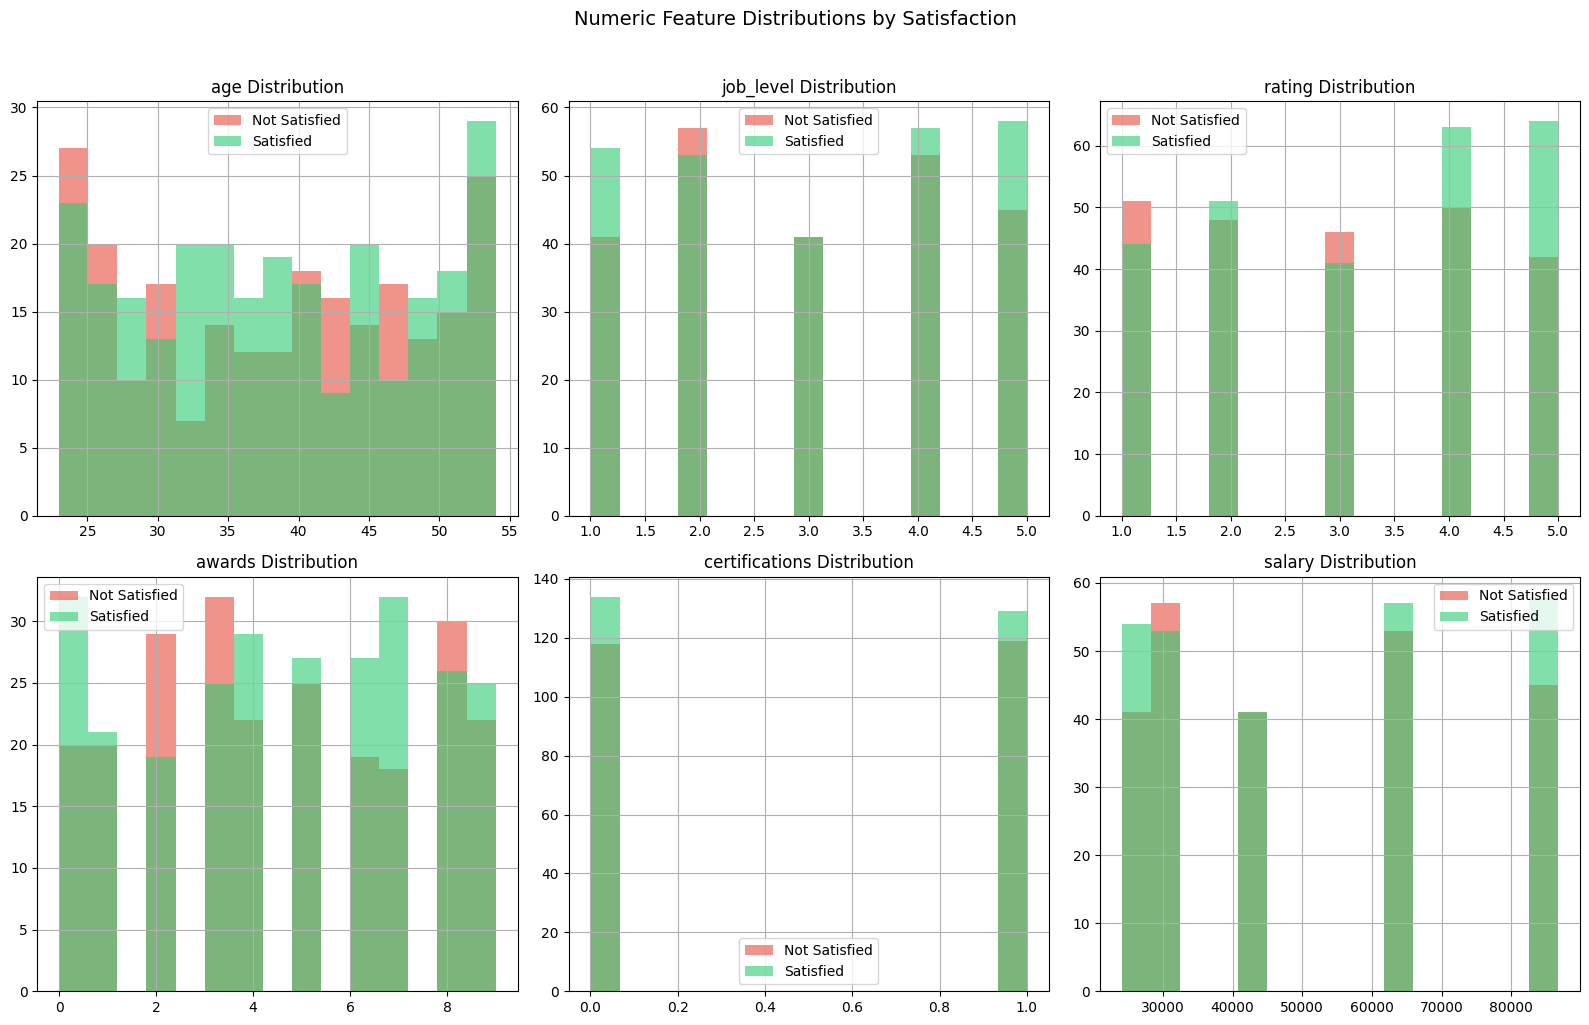

In [24]:
numeric_cols = ['age', 'job_level', 'rating', 'awards', 'certifications', 'salary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[df['satisfied'] == 0][col].hist(ax=axes[i], alpha=0.6, color='#e74c3c', label='Not Satisfied', bins=15)
    df[df['satisfied'] == 1][col].hist(ax=axes[i], alpha=0.6, color='#2ecc71', label='Satisfied', bins=15)
    axes[i].set_title(f'{col} Distribution')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Satisfaction', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## **Satisfaction rate across categorical features**

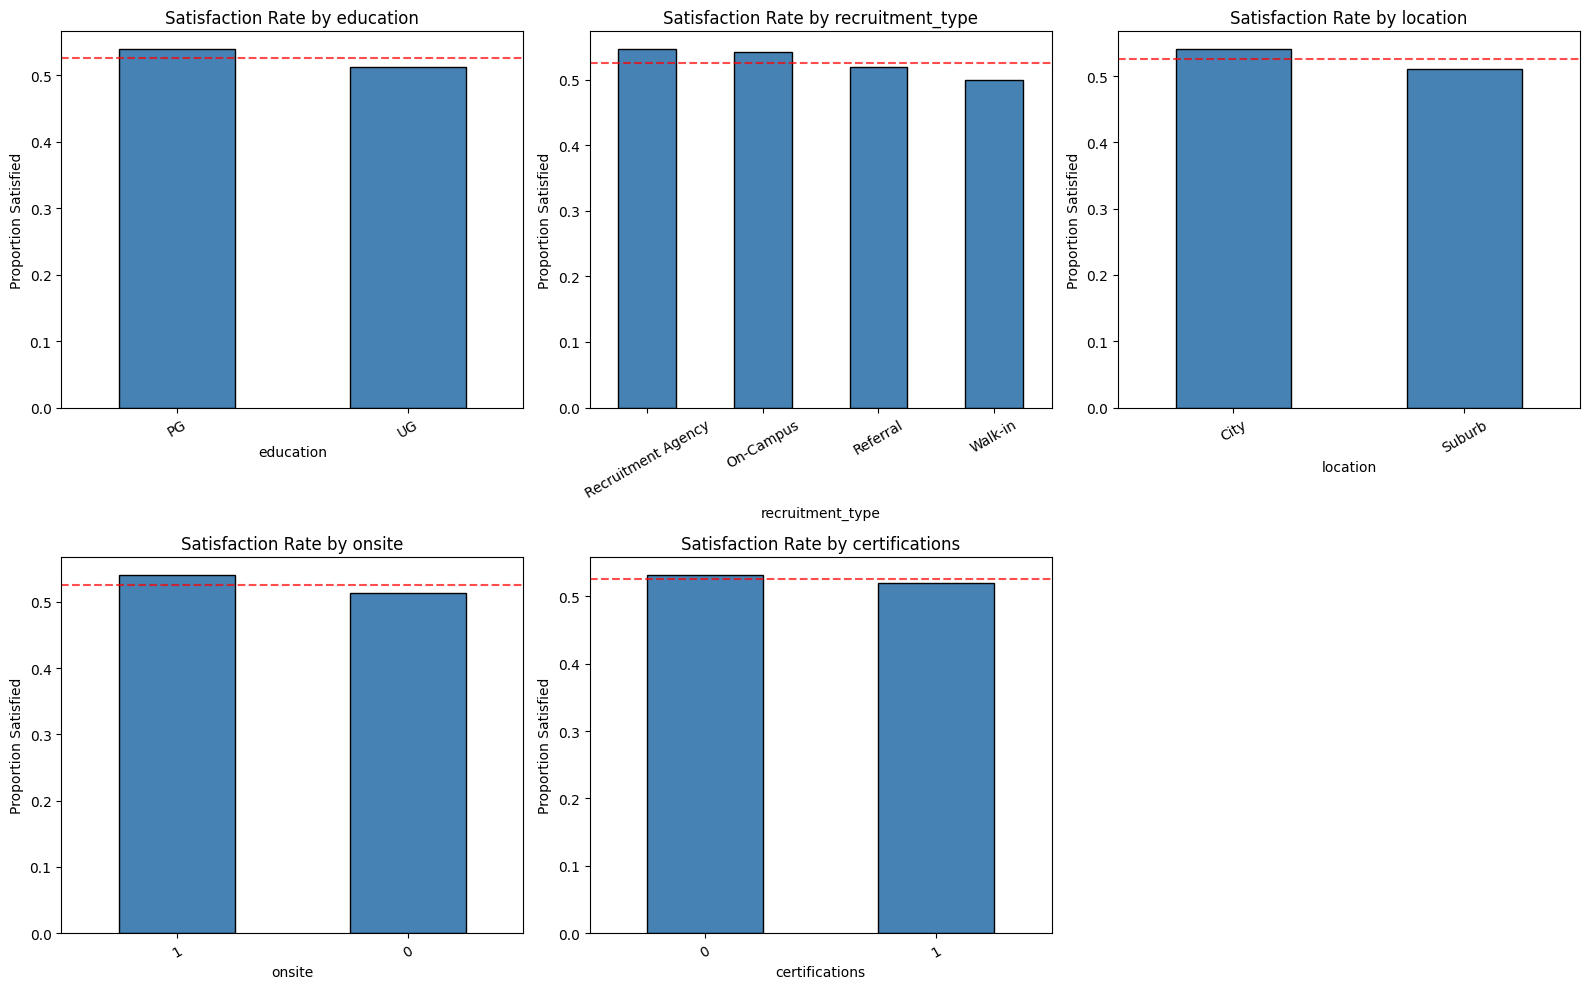

In [25]:
cat_cols = ['education', 'recruitment_type', 'location', 'onsite', 'certifications']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sat_rate = df.groupby(col)['satisfied'].mean().sort_values(ascending=False)
    sat_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Satisfaction Rate by {col}')
    axes[i].set_ylabel('Proportion Satisfied')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)
    axes[i].axhline(df['satisfied'].mean(), color='red', linestyle='--', alpha=0.7)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## **Correlation heatmap (numeric features only)**

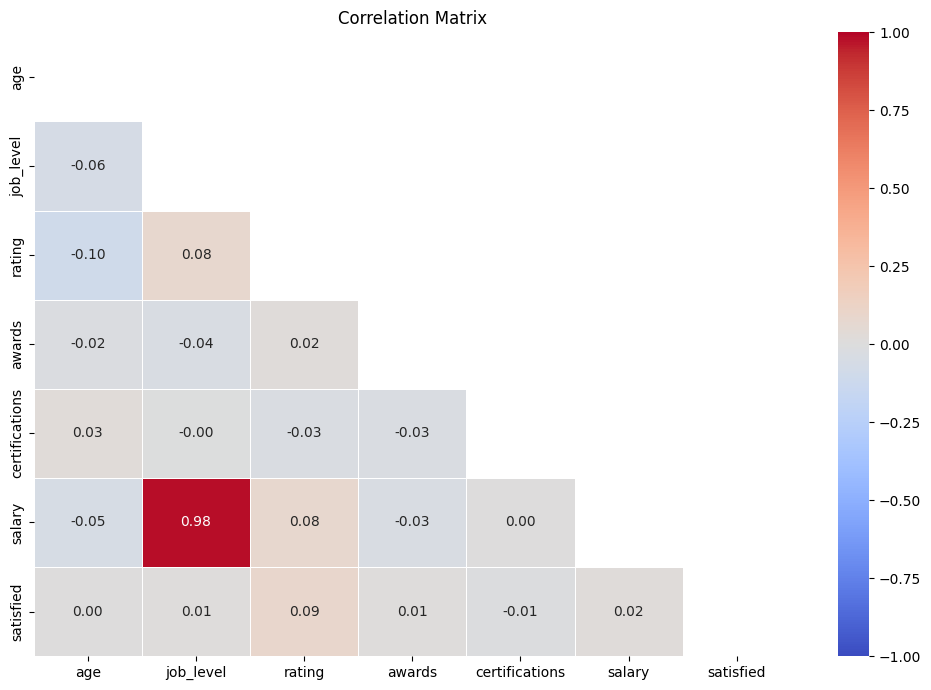

In [26]:
numeric_df = df[numeric_cols + ['satisfied']]

plt.figure(figsize=(10, 7))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## **Age Analysis**

### **Analyze age mean, median and skewness**

In [27]:
age_mean = df['age'].mean()
age_median = df['age'].median()

print("Age mean =", age_mean)
print("Age median =", age_median)

skewness = df['age'].skew()
print("Skewness of 'age' feature is = ", skewness)

Age mean = 38.61
Age median = 39.0
Skewness of 'age' feature is =  -0.006242994909121341


**Obeservations**
* There seems to be **almost no outliers** as the **mean and the median are nearly equal.**
* **The data is also not skewed**. The skewness is in between -1 and 1. In fact, **the skewness is nearly zero**.

### **Age VS Satisfaction**

In [28]:
# Calculate Count, Sum, Mean (Satisfaction Rate), and Variance per Age group
stats = df.groupby('age')['satisfied'].agg(['count', 'sum', 'mean', 'var'])


stats.columns = ['Count', 'Sum of Satisfied', 'Satisfaction_rate', 'Variance']
stats["Satisfaction_rate"] = stats["Satisfaction_rate"] * 100

# Rounding flaot precision to only two decimal places
pd.options.display.float_format = '{:.2f}'.format

print(stats)

print('-'*60, "\n\nSatisfaction rate of most age group = ",stats['Satisfaction_rate'].mode()[0])

     Count  Sum of Satisfied  Satisfaction_rate  Variance
age                                                      
23      12                 7              58.33      0.27
24      19                10              52.63      0.26
25      19                 6              31.58      0.23
26      19                 8              42.11      0.26
27      18                 9              50.00      0.26
28      15                 8              53.33      0.27
29      11                 8              72.73      0.22
30      17                 6              35.29      0.24
31      13                 7              53.85      0.27
32      10                 8              80.00      0.18
33      17                12              70.59      0.22
34      14                 7              50.00      0.27
35      20                13              65.00      0.24
36      12                 6              50.00      0.27
37      16                10              62.50      0.25
38       9    

**Observations**

*Note: low variance signifies the age group is consistent in terms satisfied or not*

* Most people of age 29, 33 and age 32 are, reportedly, **satisfied** with their job. Their satisfied rate is **~70.0% to ~80.0%**.
* Most people of age 35, 30 and 47 are, reportedly, **not satisfied** with their job. Their satisfied rate is **~30.0%**.
* Most people have satisfaction rate of **~50.0%**.

### **Boxplot: age vs satisfied**

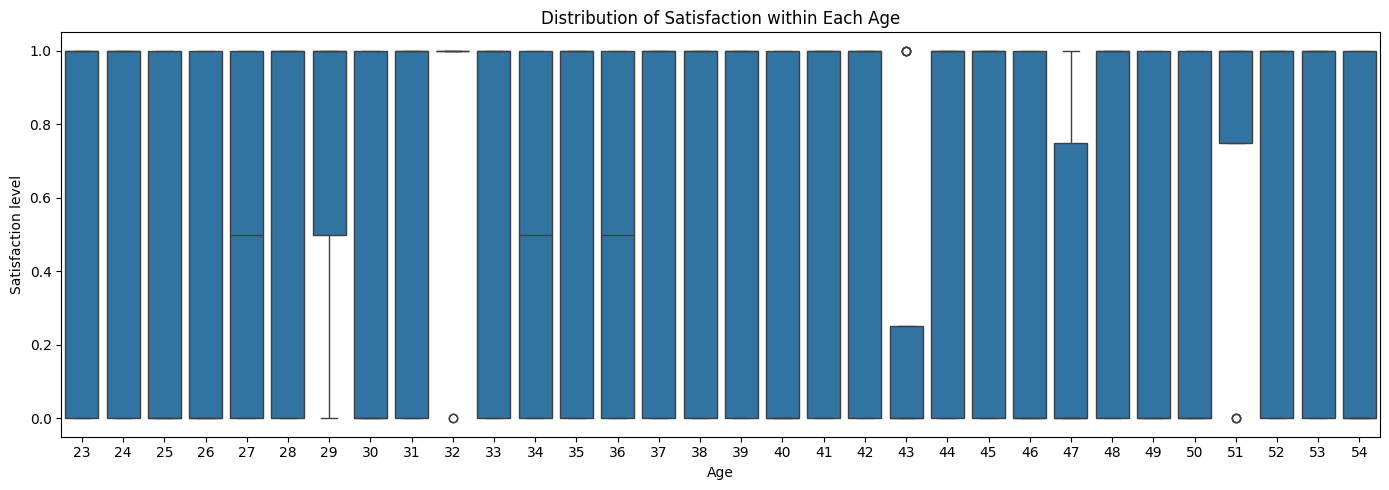

In [29]:
plt.figure(figsize=(14,5))

sns.boxplot(data=df, x='age', y='satisfied')
plt.ylabel("Satisfaction level")
plt.xlabel("Age")
plt.title("Distribution of Satisfaction within Each Age")

plt.tight_layout()
plt.show()


**From the boxplot, following obeservations have been obtained:**
* Almost all people of age 32, are reportedly staisfied, with few being dissatisfied.
* There are rougly equal number of people of age 27, 34, and 36 who are both satisfied and not satisfied.
* There is a large number of people of age 51 who are satisfied, and of age 43 who are not.
* People of age 23, 24, 25, etc., whose boxplot's median line is hidden, are mostly satisfied or dissatisfied which is not clear.

* **There are almost no outliers in 'age' feature in terms of being satisfied or not**

## **Location Analysis**

* **Employee distribution by location**
* **Satisfaction rate per location**

In [30]:
employee_location = df.groupby("location").describe()

print(employee_location,"\n\n","-"*80, "\nSatisfaction rate per location")


emp_loc_satis_rate = employee_location["satisfied"]["mean"] * 100
emp_loc_satis_rate

            age                                          job_level       ...  \
          count  mean  std   min   25%   50%   75%   max     count mean  ...   
location                                                                 ...   
City     259.00 38.08 9.28 23.00 30.00 38.00 46.00 54.00    259.00 3.04  ...   
Suburb   241.00 39.18 9.59 23.00 31.00 39.00 48.00 54.00    241.00 3.02  ...   

           salary          satisfied                                     
              75%      max     count mean  std  min  25%  50%  75%  max  
location                                                                 
City     65715.00 86750.00    259.00 0.54 0.50 0.00 0.00 1.00 1.00 1.00  
Suburb   65715.00 86750.00    241.00 0.51 0.50 0.00 0.00 1.00 1.00 1.00  

[2 rows x 64 columns] 

 -------------------------------------------------------------------------------- 
Satisfaction rate per location


location
City     54.05
Suburb   51.04
Name: mean, dtype: float64

**Observation:**

* There are slightly more satisfied people living in the City than in the Suburbs.

* So, the location doesn't really differentiate whether a person is satisfied or not
because the satisfaction rate per location is nearly equal.

* However, there are slightly more satisfied employees from the **City**.

* **Bar chart of location frequency**

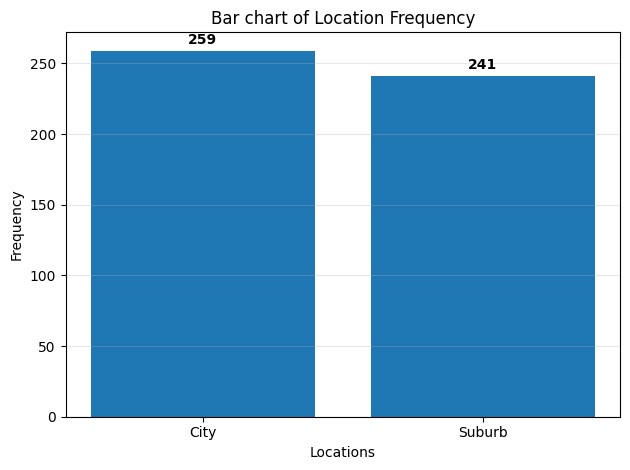

In [31]:
emp_loc = df['location'].value_counts()

plt.bar(emp_loc.index,emp_loc)

plt.grid(axis="y", alpha=0.3)
plt.title("Bar chart of Location Frequency")
plt.xlabel("Locations")
plt.ylabel("Frequency")

for i, v in enumerate(df['location'].value_counts()):
    plt.text(i,v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**So there are more satisfied people in the "City" than in the "Suburb"**

## **Department (Dept) Analysis**

* **Number of employees per department**

In [32]:
emp_dept_count = df["Dept"].value_counts()
print("Number of Employees per Department\n")
emp_dept_count

Number of Employees per Department



Dept
Purchasing    109
HR            106
Technology     98
Marketing      95
Sales          92
Name: count, dtype: int64

* **Satisfaction rate per department**

In [33]:
emp_dept = df.groupby('Dept')['satisfied'].agg(['mean']) * 100

emp_dept.columns = ["satisfied_rate"]

print(type(emp_dept))
print(emp_dept,"\n")

<class 'pandas.core.frame.DataFrame'>
            satisfied_rate
Dept                      
HR                   50.00
Marketing            46.32
Purchasing           56.88
Sales                55.43
Technology           54.08 



* **Salary distribution per department**

In [34]:
salary_dist = df.groupby('Dept')['salary'].describe()
print("Salary Distribution per Department")
salary_dist

Salary Distribution per Department


,count,mean,std,min,25%,50%,75%,max
Dept,,,,,,,,
HR,106.00,49629.76,23450.00,24076.00,29805.00,42419.00,65715.00,86750.00
Marketing,95.00,50122.66,24526.48,24076.00,26940.50,42419.00,65715.00,86750.00
Purchasing,109.00,54555.74,23443.23,24076.00,29805.00,65715.00,65715.00,86750.00
Sales,92.00,53493.08,23540.44,24076.00,29805.00,42419.00,65715.00,86750.00
Technology,98.00,44057.97,22421.53,24076.00,29805.00,29805.00,65715.00,86750.00


**Observations**

1. "HR" and "Purchasing" departments have more number of employees.
    * 106 and 109 respectively.
    * there are around dozens or more of less people in other departments.

2. All departments have nearly equal number of satisfied and not satisfied people.
    * Because they all have **~50% satisfaction rate**.
3. The people of "Marketing" department have more dissatisfied people(**~54%**) whereas it seems "Purchasing" department have more satisfied people(**~56%**).
4. There isn't much difference in salary between the people of different departments.
    * Becuase the mean salary between departments do not have significant difference.
5. It can be inferred that salary **solely** doesn't affect whether a person is satisfied or not

● **Bar chart of departments**

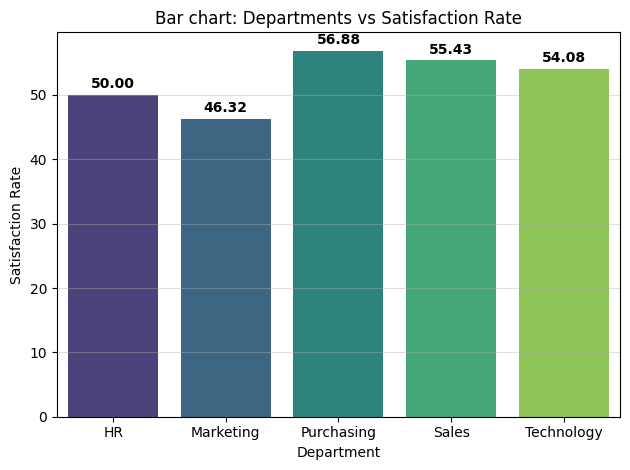

In [35]:
sns.barplot(data=emp_dept,x="Dept",y="satisfied_rate", palette='viridis')

plt.grid(axis="y",alpha=0.4)
plt.title("Bar chart: Departments vs Satisfaction Rate")
plt.ylabel("Satisfaction Rate")
plt.xlabel("Department")

for i, v in enumerate(emp_dept["satisfied_rate"].values):
    plt.text(i, v+1,str(f"{v:.2f}"),ha="center",fontweight="bold")
plt.tight_layout()
plt.show()

**Observations**

1. Hence, **"Purchasing"**, **"Sales"**, and **"Technology"** has **more than 50% satisfaction rate** but there isn't much difference.

### **Heatmap: Dept vs satisfied**

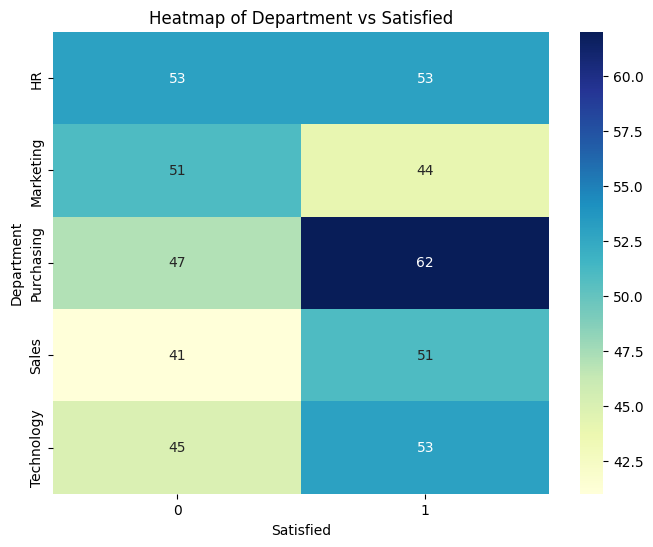

In [36]:
ct = pd.crosstab(df['Dept'], df['satisfied'])

# Step 2: Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, cmap='YlGnBu')
plt.title('Heatmap of Department vs Satisfied')
plt.ylabel('Department')
plt.xlabel('Satisfied')
plt.show()

**Observations**

* From the heatmap, it can be inferred that a person of either "Sales", or "Technology" and "Purchasing" are more satisfied than people of other departments.

## **Education Analysis**

* Education vs Salary

In [37]:
df.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1


In [38]:
edu_salary_mean = df.groupby("education")["salary"].mean()
edu_salary_mean


education
PG   50207.44
UG   50631.46
Name: salary, dtype: float64

**Analysis**: The mean salary of ***post graduates*** and ***under graduates*** seems to be nearly equal.

* Education VS Satisfaction

In [39]:
edu_salary_mean = df.groupby("education")["satisfied"].agg(['mean']) * 100
# converted mean to percentage i.e., satisfied_mean -> satisfied_percentage
edu_salary_mean.columns = ["satisfied_percent"]
print(edu_salary_mean)

           satisfied_percent
education                   
PG                     53.94
UG                     51.22


**Analysis:** Although there isn't much difference, there seems to be more number of ***post graduates*** who are satisfied. 

### **Barchart: education vs satisfied**

[53.93700787 51.2195122 ]


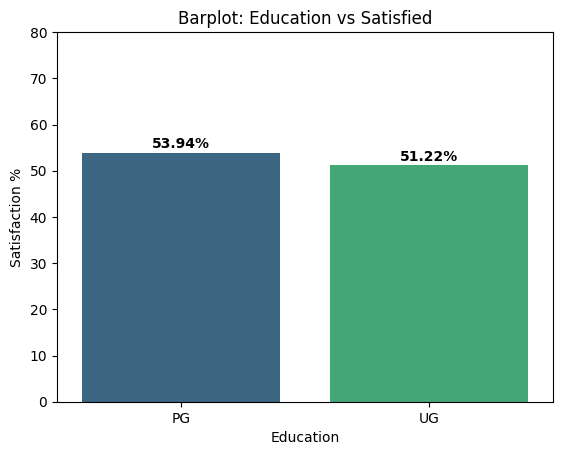

In [40]:
sns.barplot(data=edu_salary_mean, x="education", y = "satisfied_percent", palette='viridis')
plt.title("Barplot: Education vs Satisfied")
plt.xlabel("Education")
plt.ylabel("Satisfaction %")
plt.ylim(0,80)

print(edu_salary_mean["satisfied_percent"].values)

for i, v in enumerate(edu_salary_mean["satisfied_percent"].values):
    plt.text(i, v + 1, str(f"{v:.2f}%"), ha="center",fontweight="bold")

**Observation** : As analyzed before, there are more ***post graduates*** that are satisfied.

## **Recruitment Type Analysis**

* Satisfaction by recruitment type

In [41]:
df.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1


In [42]:
recruit_satisfied = df.groupby("recruitment_type")["satisfied"].agg(['mean']) * 100

recruit_satisfied.columns = ["satisfied_percent"]

print(recruit_satisfied) 

                    satisfied_percent
recruitment_type                     
On-Campus                       54.14
Recruitment Agency              54.63
Referral                        51.91
Walk-in                         50.00


**Analysis:** Although there isn't much difference, employees who were recruited **on-campus**, or through **recuritment agency** are reportedly more satisfied than employees who were recruited by other methods.

## **Job Level Analysis**

In [43]:
df.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1


* Salary by job level

In [44]:
job_lvl_salary = df.groupby("job_level")["salary"].agg(['mean'])

job_lvl_salary.columns = ['salary_mean']

job_lvl_salary

,salary_mean
job_level,
1,24076.00
2,29805.00
3,42419.00
4,65715.00
5,86750.00


**Analysis:** 
* Higher the "job_level", higher the salary amount.
* So, "job_level" 5 has the highest salary amount whereas "job_level" 1 has the lowest salary amount.

* satisfaction by "job_level"

In [45]:
job_level_satisfied = df.groupby("job_level")["satisfied"].agg(['mean']) * 100
job_level_satisfied.columns = ['satisfied_percent']
job_level_satisfied

,satisfied_percent
job_level,
1,56.84
2,48.18
3,50.00
4,51.82
5,56.31


**Analysis:** 
* Employees who have "job_level" 1 and 5, lowest and the highest "job_level" respectively, are reportedly more satisfied.
* Employees who have "job_level" 2 are less satisfied than other employees who have higher or lower "job_level".

### **Boxplot (salary vs job_level)**

Text(0, 0.5, 'Salary')

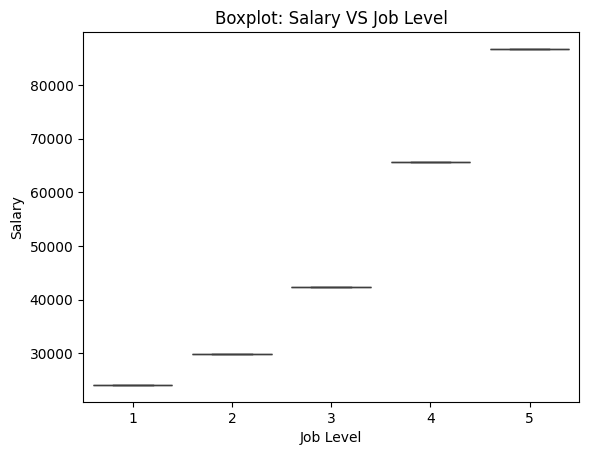

In [46]:
sns.boxplot(data = df, x = "job_level" , y = "salary")
plt.title("Boxplot: Salary VS Job Level")
plt.xlabel("Job Level")
plt.ylabel("Salary")

**Observations:**
* It seems that higher "job_level" always correspond to higher "salary".
* There are no significant outliers hence, the distribution of salary is consistent within each "job_level".
* the lowest "job_level" has the lowest median salary whereas it is the opposite for the highest "job_level".
* "job_level" is a strong predictor of "salary".

### **Heatmap (job_level vs satisfied)**

Text(0.5, 23.38159722222222, 'Satisfied')

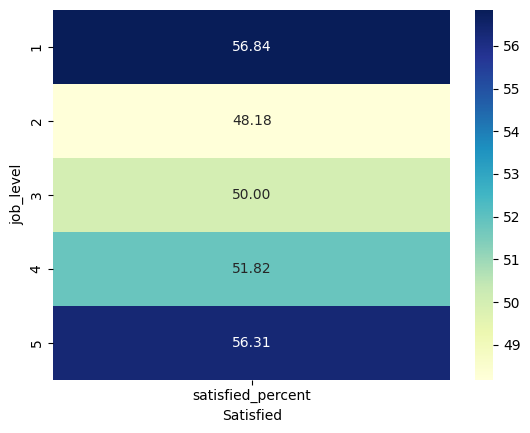

In [47]:
sns.heatmap(data = job_level_satisfied, annot=True, cmap='YlGnBu', fmt = ".2f")
plt.xlabel("Satisfied")

**Observations:**
* The highest and the lowest "job_level" have the highest number of satisfied emplpoyees.
* "job_level" 2 has the lowest number of satisfied employees.
* "job_level" 3 has equal number of satisfied and dissatisfied employees.

## **Onsite Work Analysis (onsite)**

In [48]:
df.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1


● Onsite vs remote distribution

In [49]:
onsite_satisfied_df = df.loc[(df["onsite"] == 1) & (df["satisfied"] == 1)].shape[0]
remote_satisfied_df = df.loc[(df["onsite"] == 0) & (df["satisfied"] == 1)].shape[0]

onsite_count = df[df["onsite"] == 1].value_counts().sum()
remote_count = df[df["onsite"] == 0].value_counts().sum()

onsite_remote_df = pd.DataFrame({
    "Onsite": ["remote", "onsite"],
    "count" : [remote_count, onsite_count],
    "satisfied_count": [remote_satisfied_df, onsite_satisfied_df]
})

onsite_remote_df

,Onsite,count,satisfied_count
0,remote,267,137
1,onsite,233,126


**Analysis:** 
* There are more number of employees who don't work "onsite" than who do.


In [50]:
onsite_remote_df["satisfied_percent"] = df.groupby("onsite")["satisfied"].mean() * 100

onsite_remote_df

,Onsite,count,satisfied_count,satisfied_percent
0,remote,267,137,51.31
1,onsite,233,126,54.08


**Analysis:** The satisfaction percentage of employees who work "onsite" is greater than those who don't.

### **Stacked bar (onsite vs satisfied)**

satisfied   Not Satisfied (0)  Satisfied (1)
onsite                                      
Remote (0)              48.69          51.31
Onsite (1)              45.92          54.08


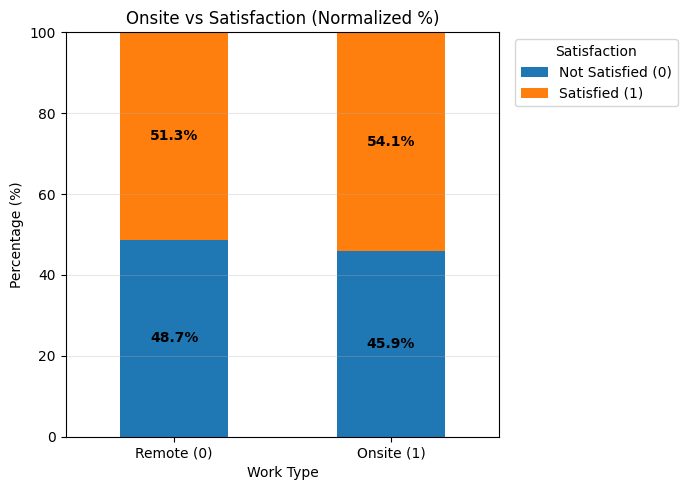

In [51]:
# Row-normalized crosstab: each onsite group sums to 100%
ct_pct = pd.crosstab(df["onsite"], df["satisfied"], normalize = "index") * 100
ct_pct = ct_pct.rename(index={0: "Remote (0)", 1: "Onsite (1)"},
                       columns={0: "Not Satisfied (0)", 1: "Satisfied (1)"})

print(ct_pct)
ax = ct_pct.plot(kind="bar", stacked=True, figsize=(7, 5), rot=0)

plt.title("Onsite vs Satisfaction (Normalized %)")
plt.xlabel("Work Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Satisfaction", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, 100)

# Annotate segment percentages
for i, (_, row) in enumerate(ct_pct.iterrows()):
    bottom = 0
    for val in row:
        if val > 4:
            ax.text(i, bottom + val / 2, f"{val:.1f}%", ha="center", va="center", fontweight="bold")
        bottom += val

plt.tight_layout()
plt.show()


**Obeservations**:
* There are more satisfied employees who work on site(**54.1%**) than who don't(**51.3%**).
* But, this work type doesn't affect much in the satisfaction of the employee.


**Conlcusion:**

No single feature could determine with sufficient confidence that an employee is satisfied or not. Hence, there is a need for Feature Engineering.

# **Feature Engineering**

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

scaler = StandardScaler()
df.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1


In [53]:
df_model = df.copy()

## **Highly correlated features removal**

Text(0.5, 36.72222222222221, 'Correlation')

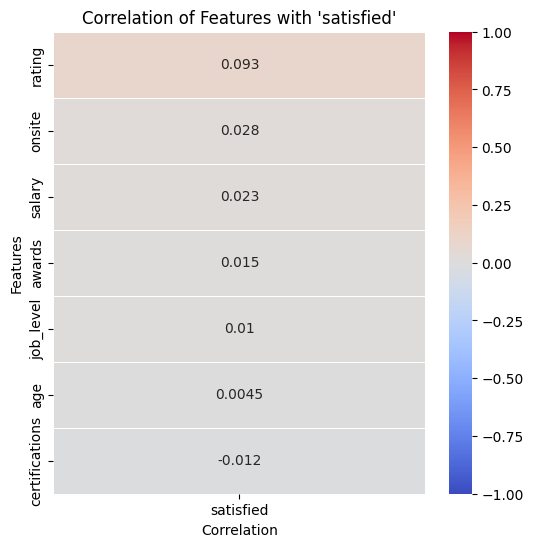

In [54]:
# 1) Ensure all columns are numeric (important after one-hot encoding)
corr = df_model.corr(numeric_only=True)

# 2) Keep only correlation with target feature
target_corr = corr[['satisfied']].drop(index='satisfied')

# 3) Optional: sort to make it easier to read
target_corr = target_corr.sort_values(by='satisfied', ascending=False)

# 4) Plot
plt.figure(figsize=(6, max(6, len(target_corr) * 0.4)))
sns.heatmap(
    target_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlation of Features with 'satisfied'")
plt.ylabel("Features")
plt.xlabel("Correlation")
# plt.tight_layout()
# plt.show()

**Conclusion**:
No need to remove any features as there are no highly correlated features in this dataset.

## **Low-Variance Feature Removal**

In [55]:
# Remove low-variance features
import pandas as pd

# Choose a numeric feature set
if 'df_model' in globals():
    X = df_model.copy()
elif 'df' in globals():
    X = df.select_dtypes(include='number').copy()
else:
    raise NameError("No dataframe found. Expected 'df_model' or 'df' in memory.")


X = X.drop(columns=['satisfied'])

variance_threshold = 0.1# increase/decrease based on your use case
feature_variances = X.var(numeric_only=True)

low_variance_cols = feature_variances[feature_variances < variance_threshold].index.tolist()
X_filtered = X.drop(columns=low_variance_cols)

print(f"Original feature count: {X.shape[1]}")
print(f"Removed low-variance features (< {variance_threshold}): {len(low_variance_cols)}")
print(f"Remaining feature count: {X_filtered.shape[1]}")

if low_variance_cols:
    print("\nRemoved columns:")
    print(low_variance_cols)
else:
    print("\nNo low-variance columns found at this threshold.")

# Preview filtered data
X_filtered.head()

Original feature count: 11
Removed low-variance features (< 0.1): 0
Remaining feature count: 11

No low-variance columns found at this threshold.


,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805


**Conclusion:** There are no low variance features, hence no features were removed.

## **Engineering Some Features**

**Potential features:**
1. `salary_per_level` = `salary` / median of salary of that `job_level`
2. `recognition_score` = `awards` + `certifications`
3. `age_group` = ["young", "mid", "senior"]
4. `under_qualified_flag` -> employees who are 'PG' with low `job_level`
4. `over_qualified_flag` -> employees who are 'UG' with high `job_level`

**Create new dataframe**

In [56]:
df_new = df_model.copy()

* '**salary_per_level**'

In [57]:
print(df_new.groupby("job_level")["salary"].agg(["min", "median", "max", "std", "nunique"]))

             min   median    max  std  nunique
job_level                                     
1          24076 24076.00  24076 0.00        1
2          29805 29805.00  29805 0.00        1
3          42419 42419.00  42419 0.00        1
4          65715 65715.00  65715 0.00        1
5          86750 86750.00  86750 0.00        1


**Conclusion:**
Since, the std of the salary in each group is 0.00, it is useless to create "salary_per_level" feature because it has low variance.

* **'recognition_score'**

In [58]:
df_new["recognition_score"] = df_model["awards"] + df_model["certifications"]

df_new.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied,recognition_score
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1,1
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0,3
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0,2
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1,0
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1,5


* **'age_group'**

In [59]:
df_model["age"].describe()

count   500.00
mean     38.61
std       9.44
min      23.00
25%      30.00
50%      39.00
75%      47.00
max      54.00
Name: age, dtype: float64

**Analysis:**
*   We can say people of 23 <= age < 30 are 'young';
    people of 30 <= age < 39 are 'mid', and above 40 are 'senior'.


**Creating `age_group` feature**

In [60]:
# 23–29: young, 30–39: mid, 40+: senior
bins = [22, 29, 39, np.inf]
labels = ['young', 'mid', 'senior']

df_new['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# quick comparison check
print(df_new[['age', 'age_group']].head())
print("\n", "-"*60)
print(df_new['age_group'].value_counts(dropna=False))

   age age_group
0   28     young
1   50    senior
2   43    senior
3   44    senior
4   33       mid

 ------------------------------------------------------------
age_group
senior    237
mid       150
young     113
Name: count, dtype: int64


* **'under_qualified_flag'**

In [61]:
# defining what "low job_level" means
low_level_cutoff = 2  

# UG=0, PG=1
df_new["under_qualified_flag"] = (
    (df_new["education"] == 1) & (df_new["job_level"] <= low_level_cutoff)
).astype(bool)

# quick check
print(df_new["under_qualified_flag"].value_counts())
df_new[["education", "job_level", "under_qualified_flag"]].head()

under_qualified_flag
False    500
Name: count, dtype: int64


,education,job_level,under_qualified_flag
0,PG,5,False
1,PG,3,False
2,UG,4,False
3,PG,2,False
4,UG,2,False


# **Encoding**

In [62]:
from sklearn.preprocessing import LabelEncoder

In [63]:
df_new.head()

,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied,recognition_score,age_group,under_qualified_flag
0,28,HR,Suburb,PG,Referral,5,2,0,1,0,86750,1,1,young,False
1,50,Technology,Suburb,PG,Walk-in,3,5,1,2,1,42419,0,3,senior,False
2,43,Technology,Suburb,UG,Referral,4,1,0,2,0,65715,0,2,senior,False
3,44,Sales,City,PG,On-Campus,2,3,1,0,0,29805,1,0,senior,False
4,33,HR,City,UG,Recruitment Agency,2,1,0,5,0,29805,1,5,mid,False


**Analysis:** 
* The features - 'Dept', 'location', and 'recruitment_type', require one-hot encoding.
* 'education' feature requires label encoding. 
* other categorical features i.e., binary data, don't need encoding at all. They are fine as they are.


In [82]:
df_encoded = df_new.copy()
# Encode categorical columns
cat_features = ['Dept', 'location', 'education', 'recruitment_type', 'age_group', 'under_qualified_flag']
le = LabelEncoder()

for col in cat_features:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print('Encoded columns:', cat_features)
print(df_encoded.shape)
df_encoded.head()

Encoded columns: ['Dept', 'location', 'education', 'recruitment_type', 'age_group', 'under_qualified_flag']
(500, 15)


,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied,recognition_score,age_group,under_qualified_flag
0,28,0,1,0,2,5,2,0,1,0,86750,1,1,2,0
1,50,4,1,0,3,3,5,1,2,1,42419,0,3,1,0
2,43,4,1,1,2,4,1,0,2,0,65715,0,2,1,0
3,44,3,0,0,0,2,3,1,0,0,29805,1,0,1,0
4,33,0,0,1,1,2,1,0,5,0,29805,1,5,0,0


In [88]:
df_encoded.to_csv("encoded_engineered_data.csv",index=False)

# **Scaling data**

In [119]:
data = pd.read_csv("encoded_engineered_data.csv")
print(data.skew())
data.head()

age                    -0.01
Dept                    0.03
location                0.07
education               0.03
recruitment_type       -0.04
job_level              -0.02
rating                 -0.08
onsite                  0.14
awards                 -0.02
certifications          0.02
salary                  0.39
satisfied              -0.10
recognition_score      -0.04
age_group               0.11
under_qualified_flag    0.00
dtype: float64


,age,Dept,location,education,recruitment_type,job_level,rating,onsite,awards,certifications,salary,satisfied,recognition_score,age_group,under_qualified_flag
0,28,0,1,0,2,5,2,0,1,0,86750,1,1,2,0
1,50,4,1,0,3,3,5,1,2,1,42419,0,3,1,0
2,43,4,1,1,2,4,1,0,2,0,65715,0,2,1,0
3,44,3,0,0,0,2,3,1,0,0,29805,1,0,1,0
4,33,0,0,1,1,2,1,0,5,0,29805,1,5,0,0


**Conclusion**: Data distribution is nearly normal

### **Defining input and target features**

In [120]:
X = data.drop(columns=['satisfied'])
y = data['satisfied']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (500, 14)
Target distribution:
satisfied
1    263
0    237
Name: count, dtype: int64


### **Spliting the data into 'train' and 'test' data**

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'Train satisfaction rate: {y_train.mean():.2%}')
print(f'Test satisfaction rate:  {y_test.mean():.2%}')

Train size: 400
Test size:  100
Train satisfaction rate: 52.50%
Test satisfaction rate:  53.00%


### **Scaling the data**

In [122]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### **Saving data**

In [123]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

# Save train and test separately
X_train_scaled_df.to_csv("X_train_scaled.csv", index=False)
X_test_scaled_df.to_csv("X_test_scaled.csv", index=False)

# **Model Training**

We train three models and compare them: Logistic Regression (baseline), Random Forest, and XGBoost.

In [124]:
X_train_scaled_df = pd.read_csv("X_train_scaled.csv")
X_test_scaled_df = pd.read_csv("X_test_scaled.csv")


X_train_scaled_np = X_train_scaled_df.to_numpy(dtype=np.float32)
X_test_scaled_np  = X_test_scaled_df.to_numpy(dtype=np.float32)

y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':              XGBClassifier(n_estimators=100, random_state=42,
                                          use_label_encoder=False, eval_metric='logloss')
}

trained = {}
for name, model in models.items():
    # Use scaled data for Logistic Regression, raw for tree models
    X_tr = X_train if name == 'Logistic Regression' else X_train
    X_te = X_test  if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    trained[name] = (model, acc)
    print(f'{name:25s} | Accuracy: {acc:.4f}')

Logistic Regression       | Accuracy: 0.4600
Random Forest             | Accuracy: 0.5400
XGBoost                   | Accuracy: 0.5200


# **Model Evaluation**

In [128]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

# Full evaluation for each model
for name, (model, _) in trained.items():
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, probs)

    print(f'\n{"=" * 45}')
    print(f'  {name}')
    print(f'{"=" * 45}')
    print(f'ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, preds,
          target_names=['Not Satisfied', 'Satisfied']))


  Logistic Regression
ROC-AUC: 0.5106
               precision    recall  f1-score   support

Not Satisfied       0.49      0.64      0.56        47
    Satisfied       0.56      0.42      0.48        53

     accuracy                           0.52       100
    macro avg       0.53      0.53      0.52       100
 weighted avg       0.53      0.52      0.51       100


  Random Forest
ROC-AUC: 0.5526
               precision    recall  f1-score   support

Not Satisfied       0.51      0.51      0.51        47
    Satisfied       0.57      0.57      0.57        53

     accuracy                           0.54       100
    macro avg       0.54      0.54      0.54       100
 weighted avg       0.54      0.54      0.54       100


  XGBoost
ROC-AUC: 0.4874
               precision    recall  f1-score   support

Not Satisfied       0.49      0.57      0.53        47
    Satisfied       0.56      0.47      0.51        53

     accuracy                           0.52       100
    macro avg